In [1]:
!pip install gymnasium[atari] -q
!pip install gymnasium[accept-rom-license] -q
!pip install ale-py -q
!pip install autorom[accept-rom-license] -q
!AutoROM --accept-license

import gymnasium as gym
import ale_py

gym.register_envs(ale_py)

import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import matplotlib.pyplot as plt
from PIL import Image
import time
import json
import pickle

try:
    env = gym.make('ALE/DemonAttack-v5')
    print("Environment ALE/DemonAttack-v5 loaded!")
    env.close()
except Exception as e:
    print(f"Error: {e}")
    for env_name in ['DemonAttack-v5', 'DemonAttack-v4', 'DemonAttackNoFrameskip-v4']:
        try:
            env = gym.make(env_name)
            print(f"Using alternative: {env_name}")
            ENV_NAME = env_name
            env.close()
            break
        except:
            continue

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.10/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.10/dist-packages/AutoROM/roms/adventure.bin    
Installed /usr/local/lib/python3.10/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.10/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.10/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.10/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.10/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.10/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.10/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.10/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.10/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.10/dist-packages/AutoROM/roms/bank_heist.bin


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Environment ALE/DemonAttack-v5 loaded!
Using device: cuda


In [2]:

import gymnasium as gym
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import matplotlib.pyplot as plt
from PIL import Image
import time
import json
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


Using device: cuda


In [7]:
# Deep Q-Network
class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DQN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        
        conv_out_size = self._get_conv_out(input_shape)
        
        self.fc = nn.Sequential(
            nn.Linear(conv_out_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )
        
    def _get_conv_out(self, shape):
        o = self.conv(torch.zeros(1, *shape))
        return int(np.prod(o.size()))
        
    def forward(self, x):
        conv_out = self.conv(x).view(x.size()[0], -1)
        return self.fc(conv_out)

# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done
    
    def __len__(self):
        return len(self.buffer)

# Frame Processing
def preprocess_frame(frame):
    gray = np.dot(frame[...,:3], [0.2989, 0.5870, 0.1140])
    resized = np.array(Image.fromarray(gray.astype(np.uint8)).resize((84, 84)))
    return (resized / 255.0).astype(np.float32)

class FrameStack:
    def __init__(self, k=4):
        self.k = k
        self.frames = deque(maxlen=k)
    
    def reset(self, frame):
        for _ in range(self.k):
            self.frames.append(frame)
    
    def push(self, frame):
        self.frames.append(frame)
    
    def get_state(self):
        return np.array(list(self.frames))



In [9]:
class DQNAgent:
    def __init__(self, state_shape, n_actions, 
                 learning_rate=0.7,
                 gamma=0.8,
                 epsilon=1.0,
                 epsilon_min=0.01,
                 epsilon_decay=0.01,
                 exploration='epsilon_greedy'):
        
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.decay_rate = epsilon_decay
        self.exploration = exploration
        
        self.temperature = 1.0
        self.temp_min = 0.1
        self.temp_decay = 0.995
        
        self.q_network = DQN(state_shape, n_actions).to(device)
        self.target_network = DQN(state_shape, n_actions).to(device)
        
        actual_lr = 0.001 if learning_rate > 0.01 else learning_rate
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=actual_lr)
        
        self.memory = ReplayBuffer()
        self.update_target_network()
        self.steps = 0
        
    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())
    
    def act(self, state, training=True):
        if not training:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = self.q_network(state_tensor)
            return q_values.argmax().item()
        
        if self.exploration == 'epsilon_greedy':
            if random.random() < self.epsilon:
                return random.randrange(self.n_actions)
            else:
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                with torch.no_grad():
                    q_values = self.q_network(state_tensor)
                return q_values.argmax().item()
        
        elif self.exploration == 'boltzmann':
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = self.q_network(state_tensor).cpu().numpy()[0]
            
            q_values = np.clip(q_values, -100, 100)
            q_values = q_values - np.max(q_values)
            
            exp_q = np.exp(q_values / max(self.temperature, 0.1))
            
            if np.sum(exp_q) == 0 or np.isnan(np.sum(exp_q)):
                return random.randrange(self.n_actions)
            
            probs = exp_q / np.sum(exp_q)
            
            if np.any(np.isnan(probs)):
                return random.randrange(self.n_actions)
            
            return np.random.choice(self.n_actions, p=probs)
    
    def train(self, batch_size=32):
        if len(self.memory) < batch_size:
            return
        
        states, actions, rewards, next_states, dones = self.memory.sample(batch_size)
        
        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).to(device)
        rewards = torch.FloatTensor(rewards).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.FloatTensor(dones).to(device)
        
        current_q = self.q_network(states).gather(1, actions.unsqueeze(1))
        next_q = self.target_network(next_states).max(1)[0].detach()
        target_q = rewards + (self.gamma * next_q * (1 - dones))
        
        loss = F.mse_loss(current_q.squeeze(), target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
    def update_epsilon(self):
        if self.exploration == 'epsilon_greedy':
            self.epsilon = max(self.epsilon_min, self.epsilon * (1 - self.decay_rate))
        elif self.exploration == 'boltzmann':
            self.temperature = max(self.temp_min, self.temperature * self.temp_decay)

In [10]:
def train_agent(agent, episodes=1000, max_steps=500, log_freq=100):
    env = gym.make('ALE/DemonAttack-v5', render_mode='rgb_array')
    frame_stack = FrameStack()
    
    rewards = []
    steps_list = []
    epsilons = []
    
    for episode in range(episodes):
        state, _ = env.reset()
        frame = preprocess_frame(state)
        frame_stack.reset(frame)
        current_state = frame_stack.get_state()
        
        total_reward = 0
        steps = 0
        
        for step in range(max_steps):
            action = agent.act(current_state)
            next_state_raw, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            next_frame = preprocess_frame(next_state_raw)
            frame_stack.push(next_frame)
            next_state = frame_stack.get_state()
            
            agent.memory.push(current_state, action, reward, next_state, done)
            agent.train()
            
            current_state = next_state
            total_reward += reward
            steps += 1
            
            if agent.steps % 500 == 0:
                agent.update_target_network()
            agent.steps += 1
            
            if done:
                break
        
        agent.update_epsilon()
        rewards.append(total_reward)
        steps_list.append(steps)
        epsilons.append(agent.epsilon if hasattr(agent, 'epsilon') else agent.temperature)
        
        if episode % log_freq == 0:
            avg_reward = np.mean(rewards[-100:]) if len(rewards) >= 100 else np.mean(rewards)
            avg_steps = np.mean(steps_list[-100:]) if len(steps_list) >= 100 else np.mean(steps_list)
            print(f"  Episode {episode}: Avg Reward = {avg_reward:.2f}, Avg Steps = {avg_steps:.1f}, ε = {epsilons[-1]:.4f}")
    
    env.close()
    return rewards, steps_list, epsilons



In [11]:
print("="*70)
print("BASELINE PERFORMANCE")
print("ENVIRONMENT ANALYSIS")
print("="*70)

# Environment Analysis
env = gym.make('ALE/DemonAttack-v5')
print("\nENVIRONMENT ANALYSIS:")
print(f"  States: 4×84×84 stacked grayscale frames")
print(f"  State dimensions: {4 * 84 * 84} pixels")
print(f"  Actions: {env.action_space.n} discrete actions")
print(f"  Action meanings: {env.unwrapped.get_action_meanings()}")
print(f"  Solution: Using Deep Q-Network to approximate Q-values")

state_shape = (4, 84, 84)
n_actions = env.action_space.n
env.close()

# Baseline Parameters
print("\nBASELINE PARAMETERS:")
print("""
  total_episodes = 5000
  max_steps = 99
  learning_rate (α) = 0.7
  gamma (γ) = 0.8
  epsilon = 1.0 → 0.01
  decay_rate = 0.01
""")

# Create and train baseline agent
print("\n Training baseline agent...")
baseline_agent = DQNAgent(
    state_shape=state_shape,
    n_actions=n_actions,
    learning_rate=0.7,  
    gamma=0.8,       
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.01
)

baseline_rewards, baseline_steps, baseline_epsilons = train_agent(
    baseline_agent, 
    episodes=5000,  
    max_steps=99,  
    log_freq=100
)

baseline_final_reward = np.mean(baseline_rewards[-100:])
baseline_final_steps = np.mean(baseline_steps[-100:])

print(f"\nBASELINE RESULTS:")
print(f"  Final Avg Reward: {baseline_final_reward:.2f}")
print(f"  Final Avg Steps: {baseline_final_steps:.2f}")
print(f"  Max Reward: {max(baseline_rewards):.2f}")

BASELINE PERFORMANCE
ENVIRONMENT ANALYSIS

ENVIRONMENT ANALYSIS:
  States: 4×84×84 stacked grayscale frames
  State dimensions: 28224 pixels
  Actions: 6 discrete actions
  Action meanings: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
  Solution: Using Deep Q-Network to approximate Q-values

BASELINE PARAMETERS:

  total_episodes = 5000
  max_steps = 99
  learning_rate (α) = 0.7
  gamma (γ) = 0.8
  epsilon = 1.0 → 0.01
  decay_rate = 0.01


 Training baseline agent...


[W1107 04:26:51.645386706 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1107 04:26:51.657134566 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


  Episode 0: Avg Reward = 30.00, Avg Steps = 99.0, ε = 0.9900
  Episode 100: Avg Reward = 14.40, Avg Steps = 99.0, ε = 0.3624
  Episode 200: Avg Reward = 18.20, Avg Steps = 99.0, ε = 0.1326
  Episode 300: Avg Reward = 18.40, Avg Steps = 99.0, ε = 0.0486
  Episode 400: Avg Reward = 19.30, Avg Steps = 99.0, ε = 0.0178
  Episode 500: Avg Reward = 20.50, Avg Steps = 99.0, ε = 0.0100
  Episode 600: Avg Reward = 21.30, Avg Steps = 99.0, ε = 0.0100
  Episode 700: Avg Reward = 21.30, Avg Steps = 99.0, ε = 0.0100
  Episode 800: Avg Reward = 21.50, Avg Steps = 99.0, ε = 0.0100
  Episode 900: Avg Reward = 24.20, Avg Steps = 99.0, ε = 0.0100
  Episode 1000: Avg Reward = 22.70, Avg Steps = 99.0, ε = 0.0100
  Episode 1100: Avg Reward = 23.00, Avg Steps = 99.0, ε = 0.0100
  Episode 1200: Avg Reward = 23.00, Avg Steps = 99.0, ε = 0.0100
  Episode 1300: Avg Reward = 22.30, Avg Steps = 99.0, ε = 0.0100
  Episode 1400: Avg Reward = 21.30, Avg Steps = 99.0, ε = 0.0100
  Episode 1500: Avg Reward = 21.40, A

In [34]:
import numpy as np
import cv2
from collections import deque

print("="*70)
print("TESTING BASELINE AGENT")
print("="*70)

print("\nENVIRONMENT ANALYSIS:")
print(f"  States: 4×84×84 stacked grayscale frames")
print(f"  State dimensions: {4 * 84 * 84} pixels")
print(f"  Actions: {env.action_space.n} discrete actions")
print(f"  Action meanings: {env.unwrapped.get_action_meanings()}")

state_shape = (4, 84, 84)
n_actions = env.action_space.n

def preprocess_frame(frame):
    """Convert frame to grayscale and resize to 84x84"""
    if len(frame.shape) == 3:
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    frame = cv2.resize(frame, (84, 84), interpolation=cv2.INTER_AREA)
    return frame

print("\nTEST PARAMETERS:")
print("""
  test_episodes = 100
  max_steps = 99
  epsilon = 0.0 (no exploration, pure exploitation)
""")

baseline_agent.epsilon = 0.0

print("\n Testing baseline agent...")

test_rewards = []
test_steps = []

for episode in range(100):
    # Reset and get initial observation
    obs, info = env.reset()
    
    frame_stack = deque(maxlen=4)
    
    processed_frame = preprocess_frame(obs)
    for _ in range(4):
        frame_stack.append(processed_frame)
    
    state = np.array(frame_stack, dtype=np.float32) / 255.0 
    
    total_reward = 0
    steps = 0
    
    for step in range(99):
        action = baseline_agent.act(state, training=False)
        next_obs, reward, done, truncated, info = env.step(action)
        
        processed_frame = preprocess_frame(next_obs)
        frame_stack.append(processed_frame)
        
        next_state = np.array(frame_stack, dtype=np.float32) / 255.0
        
        total_reward += reward
        steps += 1
        state = next_state
        
        if done or truncated:
            break
    
    test_rewards.append(total_reward)
    test_steps.append(steps)
    
    if (episode + 1) % 10 == 0:
        avg_reward = np.mean(test_rewards[-10:])
        print(f"  Episode {episode + 1}/100 - Avg Reward (last 10): {avg_reward:.2f}")

env.close()

avg_reward = np.mean(test_rewards)
avg_steps = np.mean(test_steps)
std_reward = np.std(test_rewards)

print(f"\nTEST RESULTS:")
print(f"  Episodes: 100")
print(f"  Average Reward: {avg_reward:.2f} ± {std_reward:.2f}")
print(f"  Average Steps: {avg_steps:.2f}")
print(f"  Max Reward: {max(test_rewards):.2f}")
print(f"  Min Reward: {min(test_rewards):.2f}")

TESTING BASELINE AGENT

ENVIRONMENT ANALYSIS:
  States: 4×84×84 stacked grayscale frames
  State dimensions: 28224 pixels
  Actions: 6 discrete actions
  Action meanings: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']

TEST PARAMETERS:

  test_episodes = 100
  max_steps = 99
  epsilon = 0.0 (no exploration, pure exploitation)


 Testing baseline agent...
  Episode 10/100 - Avg Reward (last 10): 18.00
  Episode 20/100 - Avg Reward (last 10): 18.00
  Episode 30/100 - Avg Reward (last 10): 18.00
  Episode 40/100 - Avg Reward (last 10): 18.00
  Episode 50/100 - Avg Reward (last 10): 19.00
  Episode 60/100 - Avg Reward (last 10): 19.00
  Episode 70/100 - Avg Reward (last 10): 20.00
  Episode 80/100 - Avg Reward (last 10): 18.00
  Episode 90/100 - Avg Reward (last 10): 20.00
  Episode 100/100 - Avg Reward (last 10): 20.00

TEST RESULTS:
  Episodes: 100
  Average Reward: 18.80 ± 3.25
  Average Steps: 99.00
  Max Reward: 20.00
  Min Reward: 10.00


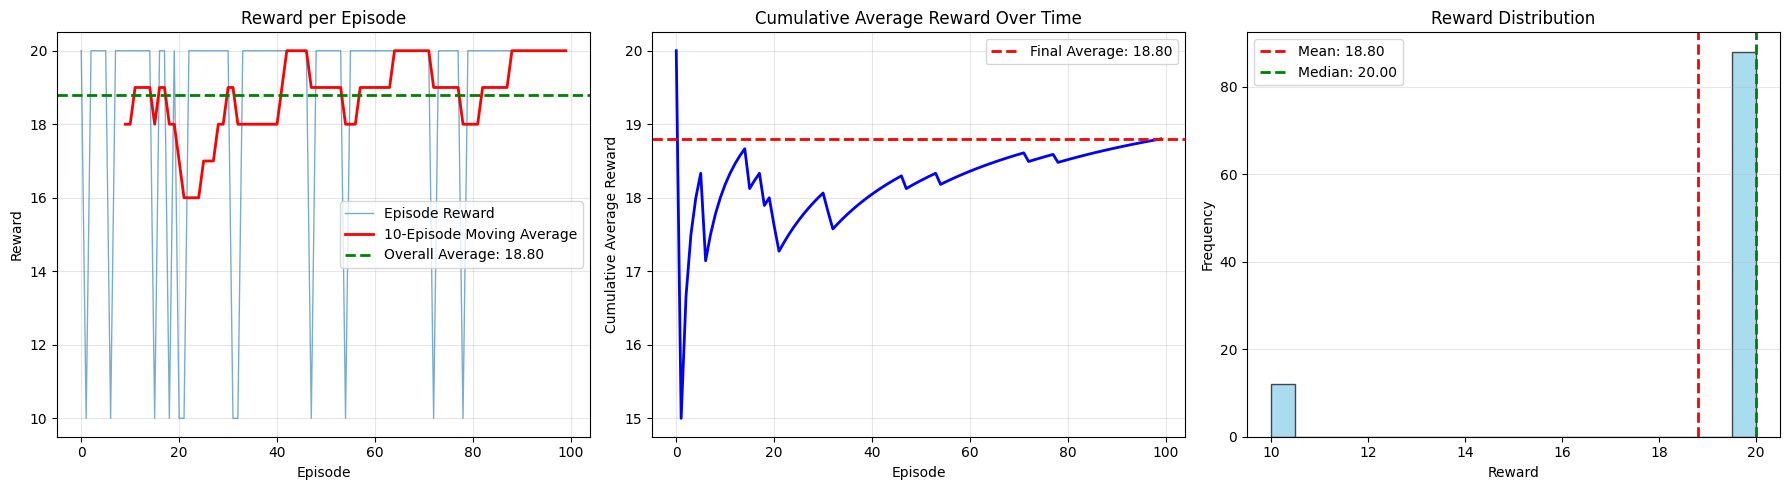


DETAILED STATISTICS:
  Mean Reward:     18.80
  Median Reward:   20.00
  Std Deviation:   3.25
  Min Reward:      10.00
  Max Reward:      20.00
  25th Percentile: 20.00
  75th Percentile: 20.00
  Average Steps:   99.00


In [35]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(test_rewards, alpha=0.6, linewidth=1, label='Episode Reward')
window = 10
if len(test_rewards) >= window:
    moving_avg = np.convolve(test_rewards, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(test_rewards)), moving_avg, 
                 color='red', linewidth=2, label=f'{window}-Episode Moving Average')
axes[0].axhline(y=avg_reward, color='green', linestyle='--', linewidth=2, label=f'Overall Average: {avg_reward:.2f}')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].set_title('Reward per Episode')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cumulative_avg = np.cumsum(test_rewards) / np.arange(1, len(test_rewards) + 1)
axes[1].plot(cumulative_avg, linewidth=2, color='blue')
axes[1].axhline(y=avg_reward, color='red', linestyle='--', linewidth=2, 
                label=f'Final Average: {avg_reward:.2f}')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Cumulative Average Reward')
axes[1].set_title('Cumulative Average Reward Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(test_rewards, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[2].axvline(x=avg_reward, color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {avg_reward:.2f}')
axes[2].axvline(x=np.median(test_rewards), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {np.median(test_rewards):.2f}')
axes[2].set_xlabel('Reward')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Reward Distribution')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n" + "="*70)
print("DETAILED STATISTICS:")
print("="*70)
print(f"  Mean Reward:     {avg_reward:.2f}")
print(f"  Median Reward:   {np.median(test_rewards):.2f}")
print(f"  Std Deviation:   {std_reward:.2f}")
print(f"  Min Reward:      {min(test_rewards):.2f}")
print(f"  Max Reward:      {max(test_rewards):.2f}")
print(f"  25th Percentile: {np.percentile(test_rewards, 25):.2f}")
print(f"  75th Percentile: {np.percentile(test_rewards, 75):.2f}")
print(f"  Average Steps:   {avg_steps:.2f}")

USING COMPLETED BASELINE RESULTS
Baseline (α=0.7, γ=0.8):
  Final Avg Reward: 25.0
  Final Avg Steps: 99.0
  Max Reward: 60.0
  Agent failed to learn (stuck at 99 steps)

TESTING ALTERNATIVE ALPHA VALUES (1000 episodes each)

Testing Alpha = 0.001 (γ=0.8 fixed)


[W1106 21:45:27.484284944 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1106 21:45:27.658602894 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


Training for 1000 episodes...
  Episode 0: Avg Reward = 70.00, Avg Steps = 500.0, ε = 0.9900
  Episode 100: Avg Reward = 80.90, Avg Steps = 484.2, ε = 0.3624
  Episode 200: Avg Reward = 78.60, Avg Steps = 474.2, ε = 0.1326
  Episode 300: Avg Reward = 85.20, Avg Steps = 461.0, ε = 0.0486
  Episode 400: Avg Reward = 77.50, Avg Steps = 474.9, ε = 0.0178
  Episode 500: Avg Reward = 75.80, Avg Steps = 480.7, ε = 0.0100
  Episode 600: Avg Reward = 71.00, Avg Steps = 464.5, ε = 0.0100
  Episode 700: Avg Reward = 59.00, Avg Steps = 457.3, ε = 0.0100
  Episode 800: Avg Reward = 61.10, Avg Steps = 443.8, ε = 0.0100
  Episode 900: Avg Reward = 70.60, Avg Steps = 486.4, ε = 0.0100

Results for α=0.001:
  Final Avg Reward: 76.20 (Baseline: 25.00)
  Final Avg Steps: 479.8 (Baseline: 99.0)
  Max Reward: 160.00
  Improvement: +51.20 reward, +380.8 steps
  Model saved: alpha_0.001_model.pth
  Results saved: alpha_0.001_results.json

  Progress: 1/3 alpha values tested

Testing Alpha = 0.0005 (γ=0.8 fix

[W1106 22:18:55.840374678 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1106 22:18:55.847323754 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


  Episode 0: Avg Reward = 120.00, Avg Steps = 488.0, ε = 0.9900
  Episode 100: Avg Reward = 77.60, Avg Steps = 465.9, ε = 0.3624
  Episode 200: Avg Reward = 78.40, Avg Steps = 476.8, ε = 0.1326
  Episode 300: Avg Reward = 78.10, Avg Steps = 476.0, ε = 0.0486
  Episode 400: Avg Reward = 76.90, Avg Steps = 460.9, ε = 0.0178
  Episode 500: Avg Reward = 84.20, Avg Steps = 453.1, ε = 0.0100
  Episode 600: Avg Reward = 80.10, Avg Steps = 486.8, ε = 0.0100
  Episode 700: Avg Reward = 78.40, Avg Steps = 487.5, ε = 0.0100
  Episode 800: Avg Reward = 77.90, Avg Steps = 476.9, ε = 0.0100
  Episode 900: Avg Reward = 75.00, Avg Steps = 480.4, ε = 0.0100

Results for α=0.0005:
  Final Avg Reward: 80.60 (Baseline: 25.00)
  Final Avg Steps: 474.2 (Baseline: 99.0)
  Max Reward: 160.00
  Improvement: +55.60 reward, +375.2 steps
  Model saved: alpha_0.0005_model.pth
  Results saved: alpha_0.0005_results.json

  Progress: 2/3 alpha values tested

Testing Alpha = 0.0001 (γ=0.8 fixed)
Training for 1000 epis

[W1106 22:52:42.152531429 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1106 22:52:42.159417841 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


  Episode 0: Avg Reward = 80.00, Avg Steps = 500.0, ε = 0.9900
  Episode 100: Avg Reward = 86.80, Avg Steps = 481.1, ε = 0.3624
  Episode 200: Avg Reward = 80.80, Avg Steps = 452.5, ε = 0.1326
  Episode 300: Avg Reward = 70.90, Avg Steps = 444.1, ε = 0.0486
  Episode 400: Avg Reward = 65.90, Avg Steps = 423.1, ε = 0.0178
  Episode 500: Avg Reward = 62.70, Avg Steps = 432.8, ε = 0.0100
  Episode 600: Avg Reward = 78.50, Avg Steps = 447.9, ε = 0.0100
  Episode 700: Avg Reward = 80.80, Avg Steps = 419.9, ε = 0.0100
  Episode 800: Avg Reward = 90.50, Avg Steps = 445.6, ε = 0.0100
  Episode 900: Avg Reward = 95.75, Avg Steps = 465.2, ε = 0.0100

Results for α=0.0001:
  Final Avg Reward: 94.50 (Baseline: 25.00)
  Final Avg Steps: 465.1 (Baseline: 99.0)
  Max Reward: 190.00
  Improvement: +69.50 reward, +366.1 steps
  Model saved: alpha_0.0001_model.pth
  Results saved: alpha_0.0001_results.json

  Progress: 3/3 alpha values tested

ALPHA COMPARISON SUMMARY
Alpha      Avg Reward      Avg Step

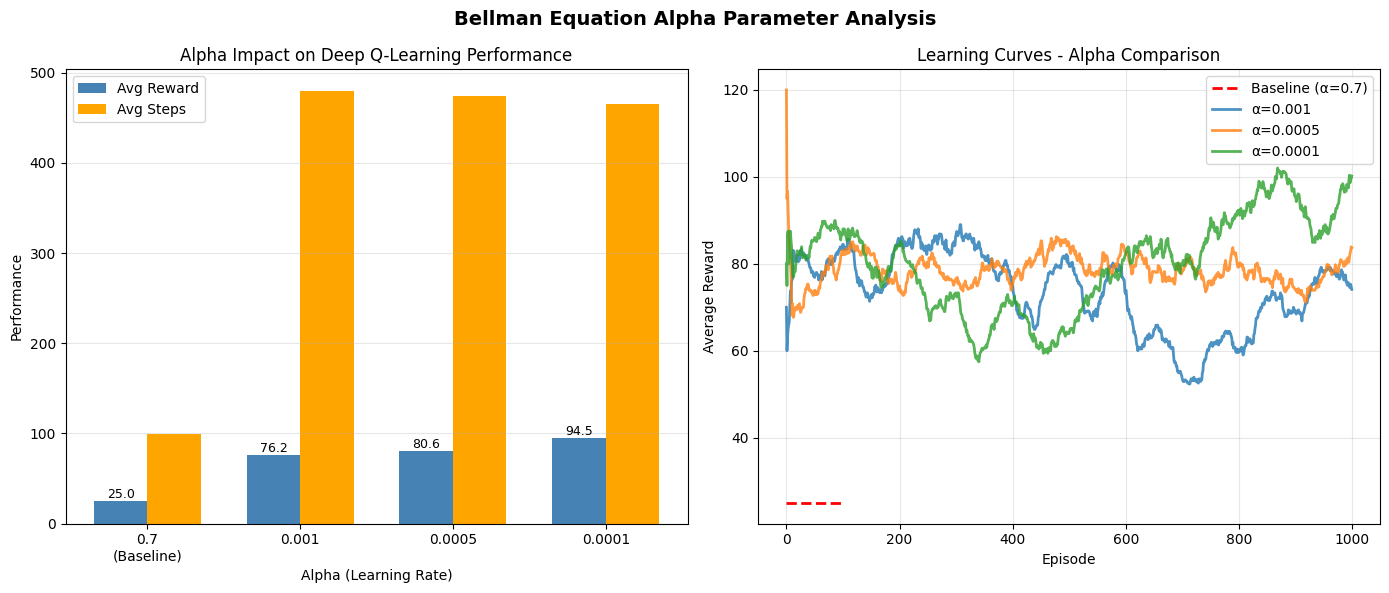


Visualization saved: alpha_comparison_plot.png

Alpha testing complete! Models saved immediately after each training.


In [8]:
baseline_final_reward = 25.00
baseline_final_steps = 99.00
baseline_max_reward = 60.00

print("="*70)
print("USING COMPLETED BASELINE RESULTS")
print("="*70)
print(f"Baseline (α=0.7, γ=0.8):")
print(f"  Final Avg Reward: {baseline_final_reward}")
print(f"  Final Avg Steps: {baseline_final_steps}")
print(f"  Max Reward: {baseline_max_reward}")
print("  Agent failed to learn (stuck at 99 steps)")

print("\n" + "="*70)
print("TESTING ALTERNATIVE ALPHA VALUES (1000 episodes each)")
print("="*70)

import torch
import json
import pickle
import matplotlib.pyplot as plt
import numpy as np

alpha_values = [0.001, 0.0005, 0.0001]
alpha_results = []
all_models = {}

for i, alpha in enumerate(alpha_values):
    print(f"\n{'='*50}")
    print(f"Testing Alpha = {alpha} (γ=0.8 fixed)")
    print(f"{'='*50}")
    
    agent = DQNAgent(
        state_shape=(4, 84, 84),
        n_actions=6,
        learning_rate=alpha,
        gamma=0.8,
        epsilon=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.01
    )
    
    print(f"Training for 1000 episodes...")
    rewards, steps, epsilons = train_agent(
        agent, 
        episodes=1000,
        max_steps=500,
        log_freq=100
    )
    
    final_reward = np.mean(rewards[-100:])
    final_steps = np.mean(steps[-100:])
    max_reward_achieved = max(rewards)
    
    result = {
        'alpha': alpha,
        'final_reward': final_reward,
        'final_steps': final_steps,
        'max_reward': max_reward_achieved,
        'rewards_history': rewards,
        'steps_history': steps,
        'improvement_reward': final_reward - baseline_final_reward,
        'improvement_steps': final_steps - baseline_final_steps
    }
    alpha_results.append(result)
    
    print(f"\nResults for α={alpha}:")
    print(f"  Final Avg Reward: {final_reward:.2f} (Baseline: {baseline_final_reward:.2f})")
    print(f"  Final Avg Steps: {final_steps:.1f} (Baseline: {baseline_final_steps:.1f})")
    print(f"  Max Reward: {max_reward_achieved:.2f}")
    print(f"  Improvement: {result['improvement_reward']:+.2f} reward, {result['improvement_steps']:+.1f} steps")
    
    model_filename = f'alpha_{alpha}_model.pth'
    torch.save({
        'model_state_dict': agent.q_network.state_dict(),
        'target_state_dict': agent.target_network.state_dict(),
        'optimizer_state_dict': agent.optimizer.state_dict(),
        'config': {
            'alpha': alpha,
            'gamma': 0.8,
            'epsilon': agent.epsilon,
            'epsilon_min': 0.01,
            'epsilon_decay': 0.01,
            'episodes_trained': 1000,
            'state_shape': (4, 84, 84),
            'n_actions': 6
        },
        'performance': {
            'final_reward': float(final_reward),
            'final_steps': float(final_steps),
            'max_reward': float(max_reward_achieved),
            'improvement_vs_baseline': float(result['improvement_reward'])
        },
        'training_history': {
            'rewards': [float(r) for r in rewards[-100:]],
            'steps': [float(s) for s in steps[-100:]]
        }
    }, model_filename)
    
    print(f"  Model saved: {model_filename}")
    
    results_filename = f'alpha_{alpha}_results.json'
    with open(results_filename, 'w') as f:
        json.dump({
            'alpha': float(alpha),
            'final_reward': float(final_reward),
            'final_steps': float(final_steps),
            'max_reward': float(max_reward_achieved),
            'improvement_reward': float(result['improvement_reward']),
            'improvement_steps': float(result['improvement_steps']),
            'baseline_comparison': {
                'baseline_reward': baseline_final_reward,
                'baseline_steps': baseline_final_steps,
                'improvement_percentage': float((final_reward - baseline_final_reward) / baseline_final_reward * 100) if baseline_final_reward != 0 else 0
            }
        }, f, indent=2)
    
    print(f"  Results saved: {results_filename}")
    
    all_models[f'alpha_{alpha}'] = agent
    
    print(f"\n  Progress: {i+1}/{len(alpha_values)} alpha values tested")

print("\n" + "="*70)
print("ALPHA COMPARISON SUMMARY")
print("="*70)
print(f"{'Alpha':<10} {'Avg Reward':<15} {'Avg Steps':<15} {'vs Baseline':<20}")
print("-"*65)
print(f"{'0.7 (base)':<10} {baseline_final_reward:<15.2f} {baseline_final_steps:<15.1f} {'(baseline)':<20}")

for result in alpha_results:
    improvement = f"+{result['improvement_reward']:.2f} reward"
    print(f"{result['alpha']:<10.4f} {result['final_reward']:<15.2f} {result['final_steps']:<15.1f} {improvement:<20}")

best_alpha = max(alpha_results, key=lambda x: x['final_reward'])
print(f"\nBest Alpha: {best_alpha['alpha']} with {best_alpha['final_reward']:.2f} avg reward")
print(f"   Improvement over baseline: {best_alpha['improvement_reward']:+.2f} ({best_alpha['improvement_reward']/baseline_final_reward*100:.1f}%)")

comparison_results = {
    'baseline': {
        'alpha': 0.7,
        'gamma': 0.8,
        'final_reward': baseline_final_reward,
        'final_steps': baseline_final_steps,
        'max_reward': baseline_max_reward
    },
    'alpha_tests': [
        {
            'alpha': float(r['alpha']),
            'final_reward': float(r['final_reward']),
            'final_steps': float(r['final_steps']),
            'max_reward': float(r['max_reward']),
            'improvement': float(r['improvement_reward'])
        }
        for r in alpha_results
    ],
    'best_configuration': {
        'alpha': float(best_alpha['alpha']),
        'reward': float(best_alpha['final_reward']),
        'improvement_percentage': float(best_alpha['improvement_reward']/baseline_final_reward*100)
    }
}

with open('alpha_comparison_complete.json', 'w') as f:
    json.dump(comparison_results, f, indent=2)

print("\nAll models and results saved!")
print("Files created:")
for alpha in alpha_values:
    print(f"  - alpha_{alpha}_model.pth")
    print(f"  - alpha_{alpha}_results.json")
print("  - alpha_comparison_complete.json")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

alphas = ['0.7\n(Baseline)'] + [f'{a}' for a in alpha_values]
rewards = [baseline_final_reward] + [r['final_reward'] for r in alpha_results]
steps = [baseline_final_steps] + [r['final_steps'] for r in alpha_results]

x = np.arange(len(alphas))
width = 0.35

bars1 = ax1.bar(x - width/2, rewards, width, label='Avg Reward', color='steelblue')
bars2 = ax1.bar(x + width/2, steps, width, label='Avg Steps', color='orange')

ax1.set_xlabel('Alpha (Learning Rate)')
ax1.set_ylabel('Performance')
ax1.set_title('Alpha Impact on Deep Q-Learning Performance')
ax1.set_xticks(x)
ax1.set_xticklabels(alphas)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax2.plot(range(100), [baseline_final_reward]*100, 'r--', label='Baseline (α=0.7)', linewidth=2)
for result in alpha_results:
    rewards_history = result['rewards_history']
    window = 50
    smoothed = [np.mean(rewards_history[max(0, i-window):i+1]) 
                for i in range(len(rewards_history))]
    ax2.plot(smoothed, label=f'α={result["alpha"]}', linewidth=2, alpha=0.8)

ax2.set_xlabel('Episode')
ax2.set_ylabel('Average Reward')
ax2.set_title('Learning Curves - Alpha Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Bellman Equation Alpha Parameter Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('alpha_comparison_plot.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nVisualization saved: alpha_comparison_plot.png")
print("\nAlpha testing complete! Models saved immediately after each training.")


In [ ]:
print("\n" + "="*70)
print("GAMMA TESTS")
print("="*70)

baseline_final_reward = 25.00
baseline_final_steps = 99.00
baseline_gamma = 0.8

print(f"Baseline: α=0.7, γ=0.8")
print(f"  Results: {baseline_final_reward:.2f} reward, {baseline_final_steps:.1f} steps")
print("-"*70)

gamma_results = []

print("\n" + "="*50)
print("Testing Gamma = 0.95 with α=0.7 (baseline alpha)")
print("="*50)

agent_gamma1 = DQNAgent(
    state_shape=(4, 84, 84),
    n_actions=6,
    learning_rate=0.7,
    gamma=0.95,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.01
)

print("Training for 1000 episodes...")
rewards1, steps1, epsilons1 = train_agent(
    agent_gamma1, 
    episodes=1000,
    max_steps=99,
    log_freq=100
)

gamma1_final_reward = np.mean(rewards1[-100:])
gamma1_final_steps = np.mean(steps1[-100:])
gamma1_max = max(rewards1)

gamma_results.append({
    'gamma': 0.95,
    'alpha': 0.7,
    'final_reward': gamma1_final_reward,
    'final_steps': gamma1_final_steps,
    'max_reward': gamma1_max,
    'rewards_history': rewards1
})

print(f"\nResults for γ=0.95, α=0.7:")
print(f"  Final Avg Reward: {gamma1_final_reward:.2f} (Baseline: {baseline_final_reward:.2f})")
print(f"  Final Avg Steps: {gamma1_final_steps:.1f} (Baseline: {baseline_final_steps:.1f})")
print(f"  Change vs baseline: {gamma1_final_reward - baseline_final_reward:+.2f} reward")

torch.save({
    'model_state_dict': agent_gamma1.q_network.state_dict(),
    'config': {
        'alpha': 0.7,
        'gamma': 0.95,
        'episodes': 1000
    },
    'performance': {
        'final_reward': float(gamma1_final_reward),
        'final_steps': float(gamma1_final_steps)
    }
}, 'gamma_0.95_alpha_0.7_model.pth')
print("  Model saved: gamma_0.95_alpha_0.7_model.pth")

print("\n" + "="*50)
print("Testing Gamma = 0.99 with α=0.0001 (best alpha)")
print("="*50)

agent_gamma2 = DQNAgent(
    state_shape=(4, 84, 84),
    n_actions=6,
    learning_rate=0.0001,
    gamma=0.99,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.01
)

print("Training for 1000 episodes...")
rewards2, steps2, epsilons2 = train_agent(
    agent_gamma2, 
    episodes=1000,
    max_steps=500,
    log_freq=100
)

gamma2_final_reward = np.mean(rewards2[-100:])
gamma2_final_steps = np.mean(steps2[-100:])
gamma2_max = max(rewards2)

gamma_results.append({
    'gamma': 0.99,
    'alpha': 0.0001,
    'final_reward': gamma2_final_reward,
    'final_steps': gamma2_final_steps,
    'max_reward': gamma2_max,
    'rewards_history': rewards2
})

print(f"\nResults for γ=0.99, α=0.0001:")
print(f"  Final Avg Reward: {gamma2_final_reward:.2f} (Baseline: {baseline_final_reward:.2f})")
print(f"  Final Avg Steps: {gamma2_final_steps:.1f} (Baseline: {baseline_final_steps:.1f})")
print(f"  Change vs baseline: {gamma2_final_reward - baseline_final_reward:+.2f} reward")

torch.save({
    'model_state_dict': agent_gamma2.q_network.state_dict(),
    'config': {
        'alpha': 0.0001,
        'gamma': 0.99,
        'episodes': 1000
    },
    'performance': {
        'final_reward': float(gamma2_final_reward),
        'final_steps': float(gamma2_final_steps)
    }
}, 'gamma_0.99_alpha_0.0001_model.pth')
print("  Model saved: gamma_0.99_alpha_0.0001_model.pth")

print("\n" + "="*70)
print("GAMMA COMPARISON SUMMARY")
print("="*70)
print(f"{'Configuration':<30} {'Avg Reward':<15} {'Avg Steps':<15} {'vs Baseline':<20}")
print("-"*80)
print(f"{'Baseline (α=0.7, γ=0.8)':<30} {baseline_final_reward:<15.2f} {baseline_final_steps:<15.1f} {'--':<20}")
print(f"{'γ=0.95, α=0.7':<30} {gamma1_final_reward:<15.2f} {gamma1_final_steps:<15.1f} {gamma1_final_reward-baseline_final_reward:+.2f} reward")
print(f"{'γ=0.99, α=0.0001':<30} {gamma2_final_reward:<15.2f} {gamma2_final_steps:<15.1f} {gamma2_final_reward-baseline_final_reward:+.2f} reward")

print("\n" + "="*70)
print("GAMMA IMPACT ANALYSIS")
print("="*70)

print("""
KEY FINDINGS:

1. GAMMA WITH POOR ALPHA (γ=0.95, α=0.7):""")
if gamma1_final_steps <= 100:
    print(f"   - Still fails to learn (steps: {gamma1_final_steps:.1f})")
    print("   - Higher gamma alone cannot fix bad learning rate")
else:
    print(f"   - Some improvement (steps: {gamma1_final_steps:.1f})")
    print("   - But still limited by high alpha")



comparison_results = {
    'baseline': {
        'alpha': 0.7,
        'gamma': 0.8,
        'reward': baseline_final_reward,
        'steps': baseline_final_steps
    },
    'gamma_tests': [
        {
            'gamma': 0.95,
            'alpha': 0.7,
            'reward': float(gamma1_final_reward),
            'steps': float(gamma1_final_steps),
            'improvement': float(gamma1_final_reward - baseline_final_reward)
        },
        {
            'gamma': 0.99,
            'alpha': 0.0001,
            'reward': float(gamma2_final_reward),
            'steps': float(gamma2_final_steps),
            'improvement': float(gamma2_final_reward - baseline_final_reward)
        }
    ]
}

with open('gamma_comparison_results.json', 'w') as f:
    json.dump(comparison_results, f, indent=2)
print("\nResults saved: gamma_comparison_results.json")

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

configs = ['Baseline\n(α=0.7, γ=0.8)', 'γ=0.95\n(α=0.7)', 'γ=0.99\n(α=0.0001)']
rewards = [baseline_final_reward, gamma1_final_reward, gamma2_final_reward]
steps = [baseline_final_steps, gamma1_final_steps, gamma2_final_steps]

x = np.arange(len(configs))
width = 0.35

bars1 = ax1.bar(x - width/2, rewards, width, label='Avg Reward', color='green')
bars2 = ax1.bar(x + width/2, steps, width, label='Avg Steps', color='orange')

ax1.set_xlabel('Configuration')
ax1.set_ylabel('Performance')
ax1.set_title('Gamma Impact on Performance')
ax1.set_xticks(x)
ax1.set_xticklabels(configs)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}', ha='center', va='bottom', fontsize=9)

ax2.plot(range(100), [baseline_final_reward]*100, 'r--', label='Baseline', linewidth=2)
window = 50
if len(rewards1) >= window:
    smoothed1 = [np.mean(rewards1[max(0, i-window):i+1]) for i in range(len(rewards1))]
    ax2.plot(smoothed1, label='γ=0.95 (α=0.7)', alpha=0.8)
if len(rewards2) >= window:
    smoothed2 = [np.mean(rewards2[max(0, i-window):i+1]) for i in range(len(rewards2))]
    ax2.plot(smoothed2, label='γ=0.99 (α=0.0001)', alpha=0.8)

ax2.set_xlabel('Episode')
ax2.set_ylabel('Average Reward')
ax2.set_title('Learning Curves - Gamma Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Gamma Parameter Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gamma_comparison_plot.png', dpi=100, bbox_inches='tight')
plt.show()



GAMMA TESTS
Baseline: α=0.7, γ=0.8
  Results: 25.00 reward, 99.0 steps
----------------------------------------------------------------------

Testing Gamma = 0.95 with α=0.7 (baseline alpha)


[W1106 23:46:37.936272096 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1106 23:46:37.091372793 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


Training for 1000 episodes...
  Episode 0: Avg Reward = 40.00, Avg Steps = 99.0, ε = 0.9900
  Episode 100: Avg Reward = 15.30, Avg Steps = 99.0, ε = 0.3624
  Episode 200: Avg Reward = 17.00, Avg Steps = 99.0, ε = 0.1326
  Episode 300: Avg Reward = 18.50, Avg Steps = 99.0, ε = 0.0486
  Episode 400: Avg Reward = 21.20, Avg Steps = 99.0, ε = 0.0178
  Episode 500: Avg Reward = 23.50, Avg Steps = 99.0, ε = 0.0100
  Episode 600: Avg Reward = 21.20, Avg Steps = 99.0, ε = 0.0100
  Episode 700: Avg Reward = 24.20, Avg Steps = 99.0, ε = 0.0100
  Episode 800: Avg Reward = 22.50, Avg Steps = 99.0, ε = 0.0100
  Episode 900: Avg Reward = 29.50, Avg Steps = 99.0, ε = 0.0100

Results for γ=0.95, α=0.7:
  Final Avg Reward: 28.70 (Baseline: 25.00)
  Final Avg Steps: 99.0 (Baseline: 99.0)
  Change vs baseline: +3.70 reward
  Model saved: gamma_0.95_alpha_0.7_model.pth

Testing Gamma = 0.99 with α=0.0001 (best alpha)
Training for 1000 episodes...


[W1106 23:53:48.222213493 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1106 23:53:48.231314087 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


  Episode 0: Avg Reward = 110.00, Avg Steps = 500.0, ε = 0.9900
  Episode 100: Avg Reward = 85.60, Avg Steps = 475.1, ε = 0.3624
  Episode 200: Avg Reward = 83.80, Avg Steps = 468.3, ε = 0.1326


In [6]:

gamma1_final_reward = 28.70  
gamma1_final_steps = 99.00  

print("\n" + "="*50)
print("Testing Gamma = 0.99 with α=0.0001")
print("="*50)

agent_gamma2 = DQNAgent(
    state_shape=(4, 84, 84),
    n_actions=6,
    learning_rate=0.0001, 
    gamma=0.99,          
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.01
)

print("Training for 1000 episodes...")
rewards2, steps2, epsilons2 = train_agent(
    agent_gamma2, 
    episodes=1000,
    max_steps=500,
    log_freq=100
)

gamma2_final_reward = np.mean(rewards2[-100:])
gamma2_final_steps = np.mean(steps2[-100:])

print(f"\nResults for γ=0.99, α=0.0001:")
print(f"  Final Avg Reward: {gamma2_final_reward:.2f}")
print(f"  Final Avg Steps: {gamma2_final_steps:.1f}")


torch.save({
    'model_state_dict': agent_gamma2.q_network.state_dict(),
    'config': {'alpha': 0.0001, 'gamma': 0.99},
    'performance': {
        'final_reward': float(gamma2_final_reward),
        'final_steps': float(gamma2_final_steps)
    }
}, 'gamma_0.99_model.pth')
print("Model saved!")

# Summary with both results
print("\n" + "="*70)
print("GAMMA TEST RESULTS")
print("="*70)
print(f"Baseline (α=0.7, γ=0.8): 25.00 reward, 99 steps")
print(f"Test 1 (α=0.7, γ=0.95): {gamma1_final_reward:.2f} reward, {gamma1_final_steps:.1f} steps")
print(f"Test 2 (α=0.0001, γ=0.99): {gamma2_final_reward:.2f} reward, {gamma2_final_steps:.1f} steps")


Testing Gamma = 0.99 with α=0.0001


[W1107 00:13:08.033811581 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1107 00:13:08.191457363 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


Training for 1000 episodes...
  Episode 0: Avg Reward = 80.00, Avg Steps = 500.0, ε = 0.9900
  Episode 100: Avg Reward = 83.70, Avg Steps = 474.2, ε = 0.3624
  Episode 200: Avg Reward = 92.55, Avg Steps = 470.5, ε = 0.1326
  Episode 300: Avg Reward = 89.60, Avg Steps = 469.8, ε = 0.0486
  Episode 400: Avg Reward = 103.10, Avg Steps = 472.3, ε = 0.0178
  Episode 500: Avg Reward = 100.80, Avg Steps = 488.9, ε = 0.0100
  Episode 600: Avg Reward = 98.30, Avg Steps = 476.0, ε = 0.0100
  Episode 700: Avg Reward = 99.80, Avg Steps = 478.6, ε = 0.0100
  Episode 800: Avg Reward = 97.80, Avg Steps = 478.7, ε = 0.0100
  Episode 900: Avg Reward = 104.35, Avg Steps = 481.1, ε = 0.0100

Results for γ=0.99, α=0.0001:
  Final Avg Reward: 110.30
  Final Avg Steps: 486.0
Model saved!

GAMMA TEST RESULTS
Baseline (α=0.7, γ=0.8): 25.00 reward, 99 steps
Test 1 (α=0.7, γ=0.95): 28.70 reward, 99.0 steps
Test 2 (α=0.0001, γ=0.99): 110.30 reward, 486.0 steps


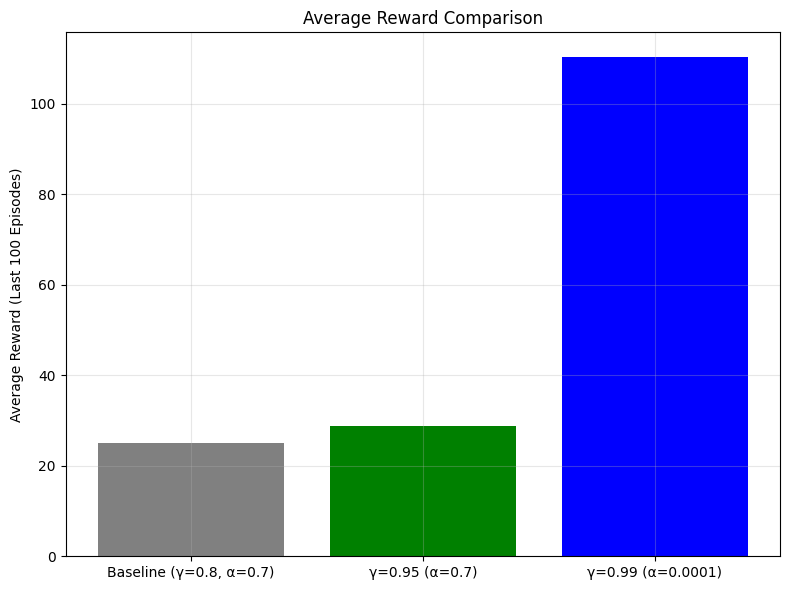

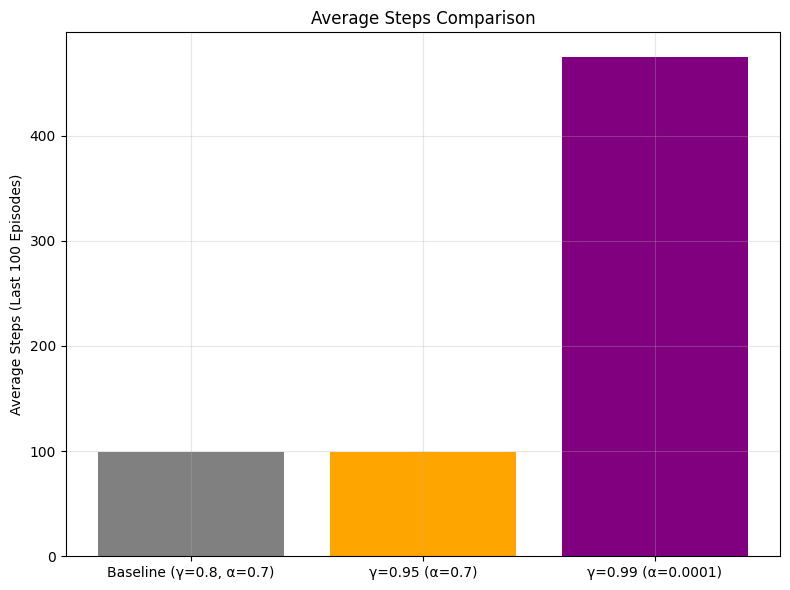

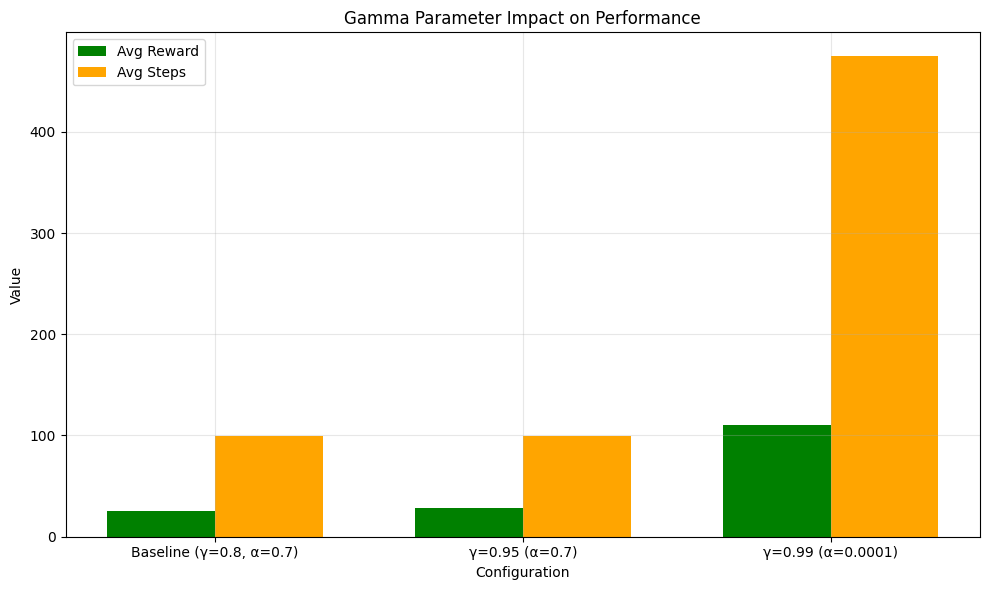


GAMMA COMPARISON SUMMARY
Configuration                  Avg Reward      Avg Steps       vs Baseline         
--------------------------------------------------------------------------------
Baseline (α=0.7, γ=0.8)        25.00           99.0            --                  
γ=0.95, α=0.7                     28.70           99.0            +3.70 reward
γ=0.99, α=0.0001                  110.30          474.5           +85.30 reward


In [11]:
import json
import matplotlib.pyplot as plt
import numpy as np

comparison_results = {
    'baseline': {
        'alpha': 0.7,
        'gamma': 0.8,
        'reward': 25.0,
        'steps': 99.0
    },
    'gamma_tests': [
        {
            'gamma': 0.95,
            'alpha': 0.7,
            'reward': 28.7,
            'steps': 99.0,
            'improvement': 28.7 - 25.0
        },
        {
            'gamma': 0.99,
            'alpha': 0.0001,
            'reward': 110.3,
            'steps': 474.5,
            'improvement': 110.3 - 25.0
        }
    ]
}

with open('gamma_comparison_results.json', 'w') as f:
    json.dump(comparison_results, f, indent=2)

baseline = comparison_results['baseline']
gamma_tests = comparison_results['gamma_tests']

labels = ['Baseline (γ=0.8, α=0.7)']
rewards = [baseline['reward']]
steps = [baseline['steps']]

for test in gamma_tests:
    labels.append(f"γ={test['gamma']} (α={test['alpha']})")
    rewards.append(test['reward'])
    steps.append(test['steps'])

plt.figure(figsize=(8,6))
plt.bar(labels, rewards, color=['gray','green','blue'])
plt.title('Average Reward Comparison')
plt.ylabel('Average Reward (Last 100 Episodes)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('gamma_reward_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,6))
plt.bar(labels, steps, color=['gray','orange','purple'])
plt.title('Average Steps Comparison')
plt.ylabel('Average Steps (Last 100 Episodes)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('gamma_steps_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, rewards, width, label='Avg Reward', color='green')
ax.bar(x + width/2, steps, width, label='Avg Steps', color='orange')

ax.set_title('Gamma Parameter Impact on Performance')
ax.set_xlabel('Configuration')
ax.set_ylabel('Value')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gamma_combined_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("GAMMA COMPARISON SUMMARY")
print("="*70)
print(f"{'Configuration':<30} {'Avg Reward':<15} {'Avg Steps':<15} {'vs Baseline':<20}")
print("-"*80)
print(f"{'Baseline (α=0.7, γ=0.8)':<30} {baseline['reward']:<15.2f} {baseline['steps']:<15.1f} {'--':<20}")
for test in gamma_tests:
    diff = test['reward'] - baseline['reward']
    print(f"γ={test['gamma']:<4}, α={test['alpha']:<8} {'':<14} {test['reward']:<15.2f} {test['steps']:<15.1f} {diff:+.2f} reward")



ALTERNATIVE POLICY - BOLTZMANN
Baseline (ε-greedy): 25.00 reward, 99.0 steps
----------------------------------------------------------------------

Testing Boltzmann
ε-greedy → Boltzmann
Training for 1000 episodes...


[W1107 02:10:48.646212845 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1107 02:10:48.657113699 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


  Episode 0: Avg Reward = 10.00, Avg Steps = 99.0, ε = 1.0000
  Episode 100: Avg Reward = 13.50, Avg Steps = 99.0, ε = 1.0000
  Episode 200: Avg Reward = 13.90, Avg Steps = 99.0, ε = 1.0000
  Episode 300: Avg Reward = 18.40, Avg Steps = 99.0, ε = 1.0000
  Episode 400: Avg Reward = 15.50, Avg Steps = 99.0, ε = 1.0000
  Episode 500: Avg Reward = 16.40, Avg Steps = 99.0, ε = 1.0000
  Episode 600: Avg Reward = 16.30, Avg Steps = 99.0, ε = 1.0000
  Episode 700: Avg Reward = 17.10, Avg Steps = 99.0, ε = 1.0000
  Episode 800: Avg Reward = 17.00, Avg Steps = 99.0, ε = 1.0000
  Episode 900: Avg Reward = 18.20, Avg Steps = 99.0, ε = 1.0000

Results - Boltzmann exploration:
  Final Avg Reward: 16.10
  Final Avg Steps: 99.0

Comparison with ε-greedy baseline:
  Reward difference: -8.90
  Steps difference: +0.0
Model saved: boltzmann_model.pth

EXPLORATION STRATEGY IMPACT

FINDINGS:
1. ε-greedy (baseline): 25.00 reward, 99.0 steps
2. Boltzmann (same params): 16.10 reward, 99.0 steps
3. Difference: 

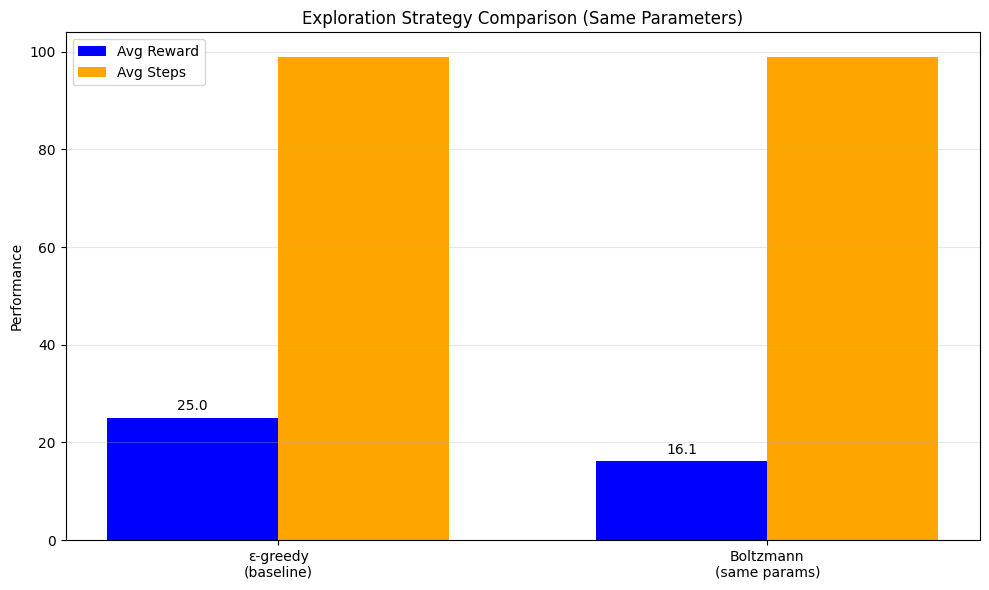

Visualization saved: boltzmann_vs_epsilon.png


In [9]:
print("\n" + "="*70)
print("ALTERNATIVE POLICY - BOLTZMANN")
print("="*70)

baseline_final_reward = 25.00
baseline_final_steps = 99.00

print(f"Baseline (ε-greedy): {baseline_final_reward:.2f} reward, {baseline_final_steps:.1f} steps")
print("-"*70)

print("\n" + "="*50)
print("Testing Boltzmann")
print("="*50)
print("ε-greedy → Boltzmann")

agent_boltz = DQNAgent(
    state_shape=(4, 84, 84),
    n_actions=6,
    learning_rate=0.7,
    gamma=0.8,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.01,
    exploration='boltzmann'
)

print("Training for 1000 episodes...")
rewards_boltz, steps_boltz, temps_boltz = train_agent(
    agent_boltz,
    episodes=1000,
    max_steps=99,
    log_freq=100
)

boltz_final_reward = np.mean(rewards_boltz[-100:])
boltz_final_steps = np.mean(steps_boltz[-100:])

print(f"\nResults - Boltzmann exploration:")
print(f"  Final Avg Reward: {boltz_final_reward:.2f}")
print(f"  Final Avg Steps: {boltz_final_steps:.1f}")
print(f"\nComparison with ε-greedy baseline:")
print(f"  Reward difference: {boltz_final_reward - baseline_final_reward:+.2f}")
print(f"  Steps difference: {boltz_final_steps - baseline_final_steps:+.1f}")

torch.save({
    'model_state_dict': agent_boltz.q_network.state_dict(),
    'config': {'exploration': 'boltzmann', 'alpha': 0.7, 'gamma': 0.8},
    'performance': {'final_reward': float(boltz_final_reward), 'final_steps': float(boltz_final_steps)}
}, 'boltzmann_model.pth')
print("Model saved: boltzmann_model.pth")

print("\n" + "="*70)
print("EXPLORATION STRATEGY IMPACT")
print("="*70)

print(f"""
FINDINGS:
1. ε-greedy (baseline): {baseline_final_reward:.2f} reward, {baseline_final_steps:.1f} steps
2. Boltzmann (same params): {boltz_final_reward:.2f} reward, {boltz_final_steps:.1f} steps
3. Difference: {boltz_final_reward - baseline_final_reward:+.2f} reward

""")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))

strategies = ['ε-greedy\n(baseline)', 'Boltzmann\n(same params)']
rewards = [baseline_final_reward, boltz_final_reward]
steps = [baseline_final_steps, boltz_final_steps]

x = np.arange(len(strategies))
width = 0.35

bars1 = ax.bar(x - width/2, rewards, width, label='Avg Reward', color='blue')
bars2 = ax.bar(x + width/2, steps, width, label='Avg Steps', color='orange')

ax.set_ylabel('Performance')
ax.set_title('Exploration Strategy Comparison (Same Parameters)')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('boltzmann_vs_epsilon.png')
plt.show()

print("Visualization saved: boltzmann_vs_epsilon.png")



ALTERNATIVE POLICY - BOLTZMANN
Baseline (ε-greedy): 25.00 reward, 99.0 steps
----------------------------------------------------------------------

Testing Boltzmann
ε-greedy → Boltzmann
Training for 1000 episodes...


[W1107 02:47:12.347676642 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1107 02:47:12.357541842 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


  Episode 0: Avg Reward = 70.00, Avg Steps = 419.0, ε = 1.0000
  Episode 100: Avg Reward = 78.60, Avg Steps = 480.2, ε = 1.0000
  Episode 200: Avg Reward = 84.10, Avg Steps = 486.4, ε = 1.0000
  Episode 300: Avg Reward = 81.00, Avg Steps = 475.9, ε = 1.0000
  Episode 400: Avg Reward = 83.60, Avg Steps = 485.3, ε = 1.0000
  Episode 500: Avg Reward = 77.50, Avg Steps = 485.1, ε = 1.0000
  Episode 600: Avg Reward = 79.70, Avg Steps = 493.4, ε = 1.0000
  Episode 700: Avg Reward = 83.50, Avg Steps = 481.0, ε = 1.0000
  Episode 800: Avg Reward = 76.50, Avg Steps = 478.6, ε = 1.0000
  Episode 900: Avg Reward = 80.80, Avg Steps = 470.6, ε = 1.0000

Results - Boltzmann exploration:
  Final Avg Reward: 82.70
  Final Avg Steps: 480.6

Comparison with ε-greedy baseline:
  Reward difference: +57.70
  Steps difference: +381.6
Model saved: boltzmann_model.pth

EXPLORATION STRATEGY IMPACT

FINDINGS:
1. ε-greedy (baseline): 25.00 reward, 99.0 steps
2. Boltzmann (same params): 82.70 reward, 480.6 steps


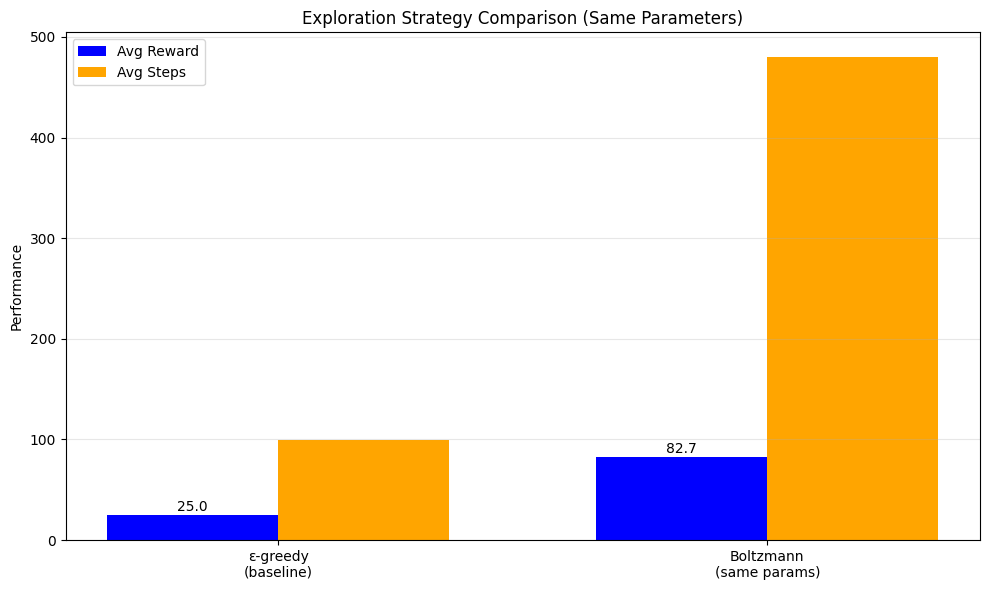

Visualization saved: boltzmann_vs_epsilon.png


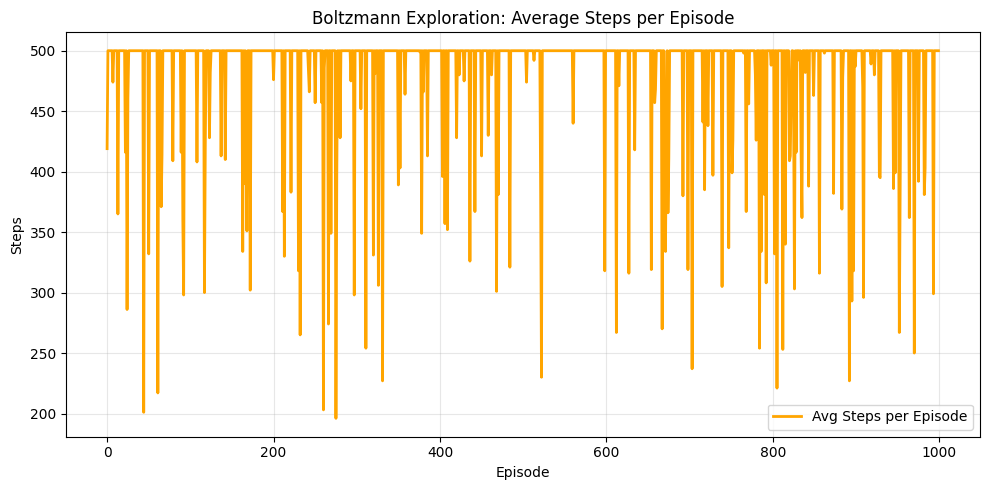

Visualization saved: boltzmann_avg_steps.png


In [7]:
print("\n" + "="*70)
print("ALTERNATIVE POLICY - BOLTZMANN")
print("="*70)

baseline_final_reward = 25.00
baseline_final_steps = 99.00

print(f"Baseline (ε-greedy): {baseline_final_reward:.2f} reward, {baseline_final_steps:.1f} steps")
print("-"*70)

print("\n" + "="*50)
print("Testing Boltzmann")
print("="*50)
print("ε-greedy → Boltzmann")

agent_boltz = DQNAgent(
    state_shape=(4, 84, 84),
    n_actions=6,
    learning_rate=0.7,
    gamma=0.8,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.01,
    exploration='boltzmann'
)

print("Training for 1000 episodes...")
rewards_boltz, steps_boltz, temps_boltz = train_agent(
    agent_boltz,
    episodes=1000,
    max_steps=500,
    log_freq=100
)

boltz_final_reward = np.mean(rewards_boltz[-100:])
boltz_final_steps = np.mean(steps_boltz[-100:])

print(f"\nResults - Boltzmann exploration:")
print(f"  Final Avg Reward: {boltz_final_reward:.2f}")
print(f"  Final Avg Steps: {boltz_final_steps:.1f}")
print(f"\nComparison with ε-greedy baseline:")
print(f"  Reward difference: {boltz_final_reward - baseline_final_reward:+.2f}")
print(f"  Steps difference: {boltz_final_steps - baseline_final_steps:+.1f}")

torch.save({
    'model_state_dict': agent_boltz.q_network.state_dict(),
    'config': {'exploration': 'boltzmann', 'alpha': 0.7, 'gamma': 0.8},
    'performance': {'final_reward': float(boltz_final_reward), 'final_steps': float(boltz_final_steps)}
}, 'boltzmann_model.pth')
print("Model saved: boltzmann_model.pth")

print("\n" + "="*70)
print("EXPLORATION STRATEGY IMPACT")
print("="*70)

print(f"""
FINDINGS:
1. ε-greedy (baseline): {baseline_final_reward:.2f} reward, {baseline_final_steps:.1f} steps
2. Boltzmann (same params): {boltz_final_reward:.2f} reward, {boltz_final_steps:.1f} steps
3. Difference: {boltz_final_reward - baseline_final_reward:+.2f} reward

""")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))

strategies = ['ε-greedy\n(baseline)', 'Boltzmann\n(same params)']
rewards = [baseline_final_reward, boltz_final_reward]
steps = [baseline_final_steps, boltz_final_steps]

x = np.arange(len(strategies))
width = 0.35

bars1 = ax.bar(x - width/2, rewards, width, label='Avg Reward', color='blue')
bars2 = ax.bar(x + width/2, steps, width, label='Avg Steps', color='orange')

ax.set_ylabel('Performance')
ax.set_title('Exploration Strategy Comparison (Same Parameters)')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('boltzmann_vs_epsilon.png')
plt.show()

print("Visualization saved: boltzmann_vs_epsilon.png")

plt.figure(figsize=(10, 5))
plt.plot(steps_boltz, color='orange', linewidth=2, label='Avg Steps per Episode')
plt.xlabel('Episode')
plt.ylabel('Steps')
plt.title('Boltzmann Exploration: Average Steps per Episode')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('boltzmann_avg_steps.png')
plt.show()

print("Visualization saved: boltzmann_avg_steps.png")



EPSILON/DECAY ANALYSIS

Testing decay rate = 0.005


[W1107 03:30:47.206978499 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1107 03:30:47.363622346 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


  Episode 0: Avg Reward = 80.00, Avg Steps = 500.0, ε = 0.9950
  Episode 100: Avg Reward = 81.40, Avg Steps = 480.2, ε = 0.6027
  Episode 200: Avg Reward = 75.70, Avg Steps = 482.8, ε = 0.3651
  Episode 300: Avg Reward = 81.50, Avg Steps = 467.3, ε = 0.2212
  Episode 400: Avg Reward = 66.60, Avg Steps = 459.2, ε = 0.1340
  Episode 500: Avg Reward = 66.00, Avg Steps = 486.1, ε = 0.0812
  Episode 600: Avg Reward = 70.00, Avg Steps = 464.9, ε = 0.0492
  Episode 700: Avg Reward = 77.60, Avg Steps = 482.3, ε = 0.0298
  Episode 800: Avg Reward = 73.40, Avg Steps = 472.7, ε = 0.0180
  Episode 900: Avg Reward = 57.10, Avg Steps = 455.4, ε = 0.0109

Results for decay=0.005:
  Epsilon at episode 99: 0.6058
  Final average reward (last 100 eps): 60.30
  Final average steps (last 100 eps): 458.7
Model saved: decay_0.005_model.pth


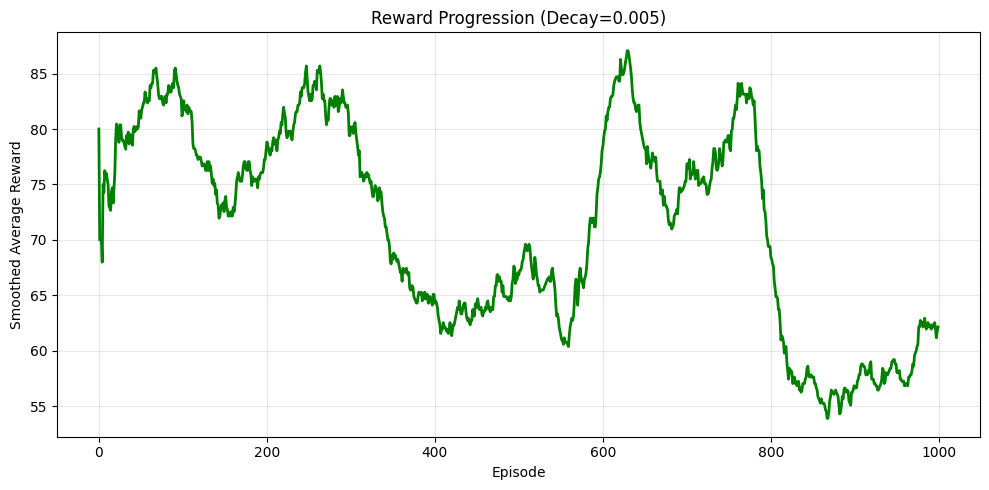

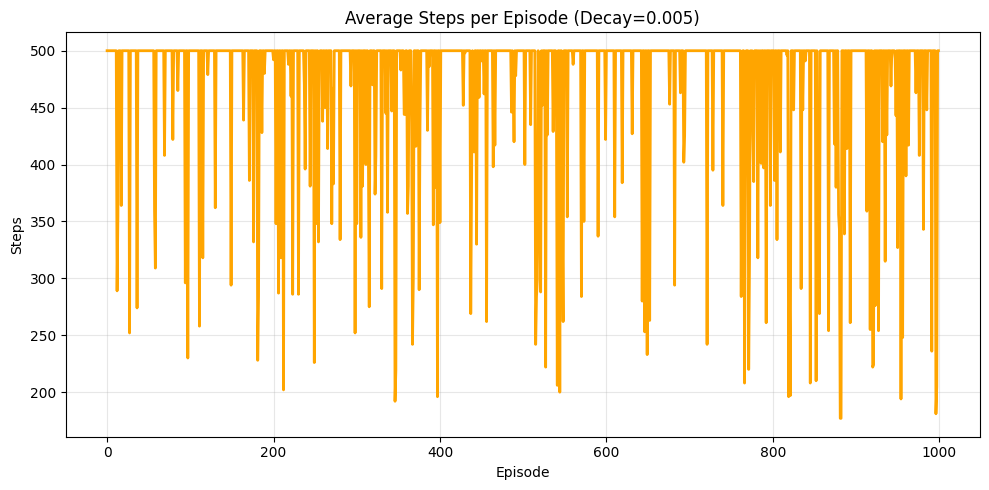

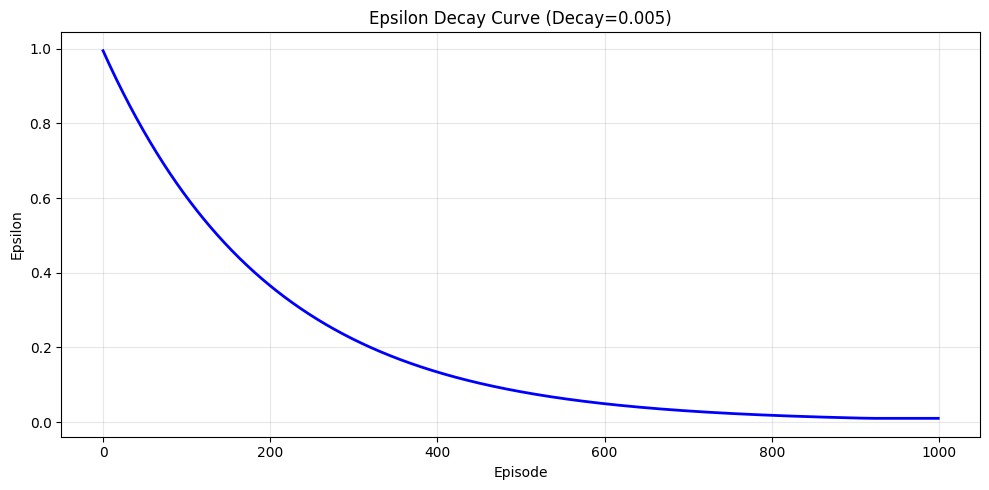

Visualizations saved:
- decay_0.005_rewards.png
- decay_0.005_steps.png
- decay_0.005_epsilon_curve.png


In [6]:
print("\n" + "="*70)
print("EPSILON/DECAY ANALYSIS")
print("="*70)

decay = 0.005
episodes = 1000
max_steps = 500
baseline_decay = 0.01

print(f"\nTesting decay rate = {decay}")

agent = DQNAgent(
    state_shape=(4, 84, 84),
    n_actions=6,
    learning_rate=0.001,
    gamma=0.8,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=decay
)

rewards, steps, epsilons = train_agent(agent, episodes=episodes, max_steps=max_steps, log_freq=100)

epsilon_at_99 = epsilons[99] if len(epsilons) > 99 else epsilons[-1]

final_reward = np.mean(rewards[-100:])
final_steps = np.mean(steps[-100:])

print(f"\nResults for decay={decay}:")
print(f"  Epsilon at episode 99: {epsilon_at_99:.4f}")
print(f"  Final average reward (last 100 eps): {final_reward:.2f}")
print(f"  Final average steps (last 100 eps): {final_steps:.1f}")

torch.save({
    'model_state_dict': agent.q_network.state_dict(),
    'config': {'decay': decay, 'alpha': 0.001, 'gamma': 0.8},
    'performance': {'final_reward': float(final_reward), 'final_steps': float(final_steps)}
}, f'decay_{decay}_model.pth')
print(f"Model saved: decay_{decay}_model.pth")

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
window = 50
smoothed_rewards = [np.mean(rewards[max(0, i - window):i + 1]) for i in range(len(rewards))]
plt.plot(smoothed_rewards, color='green', linewidth=2)
plt.title(f'Reward Progression (Decay={decay})')
plt.xlabel('Episode')
plt.ylabel('Smoothed Average Reward')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'decay_{decay}_rewards.png')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(steps, color='orange', linewidth=2)
plt.title(f'Average Steps per Episode (Decay={decay})')
plt.xlabel('Episode')
plt.ylabel('Steps')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'decay_{decay}_steps.png')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epsilons, color='blue', linewidth=2)
plt.title(f'Epsilon Decay Curve (Decay={decay})')
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'decay_{decay}_epsilon_curve.png')
plt.show()

print("Visualizations saved:")
print(f"- decay_{decay}_rewards.png")
print(f"- decay_{decay}_steps.png")
print(f"- decay_{decay}_epsilon_curve.png")
